## **5. Ejercicio en Clase**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.

In [1]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error

In [2]:
data = pd.read_excel("https://raw.githubusercontent.com/profedaniel86/Series_de_Tiempo/refs/heads/main/1.Intro/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


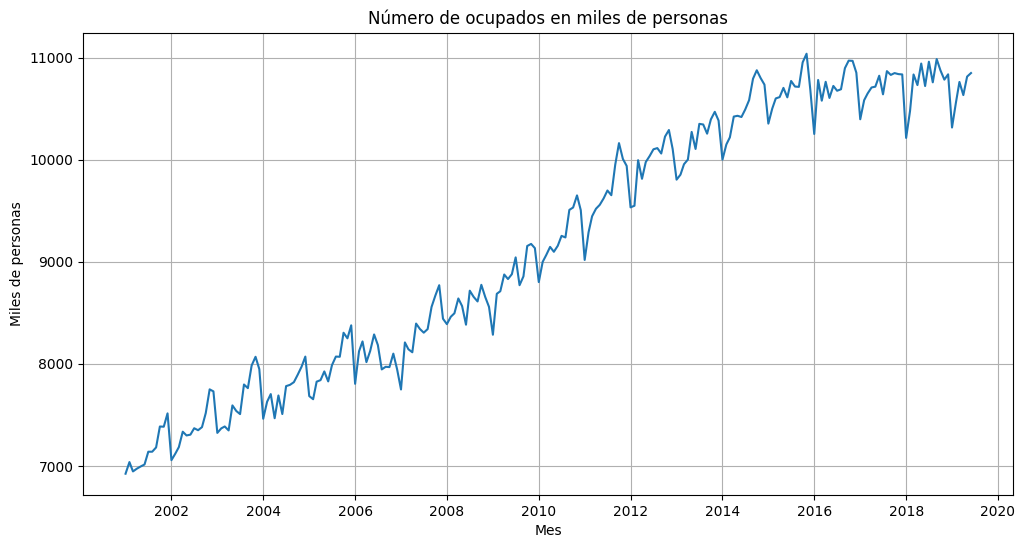

In [3]:
# Primero visualizamos la serie de ocupados

plt.figure(figsize=(12, 6))
plt.title("Número de ocupados en miles de personas")
plt.xlabel("Mes")
plt.ylabel("Miles de personas")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

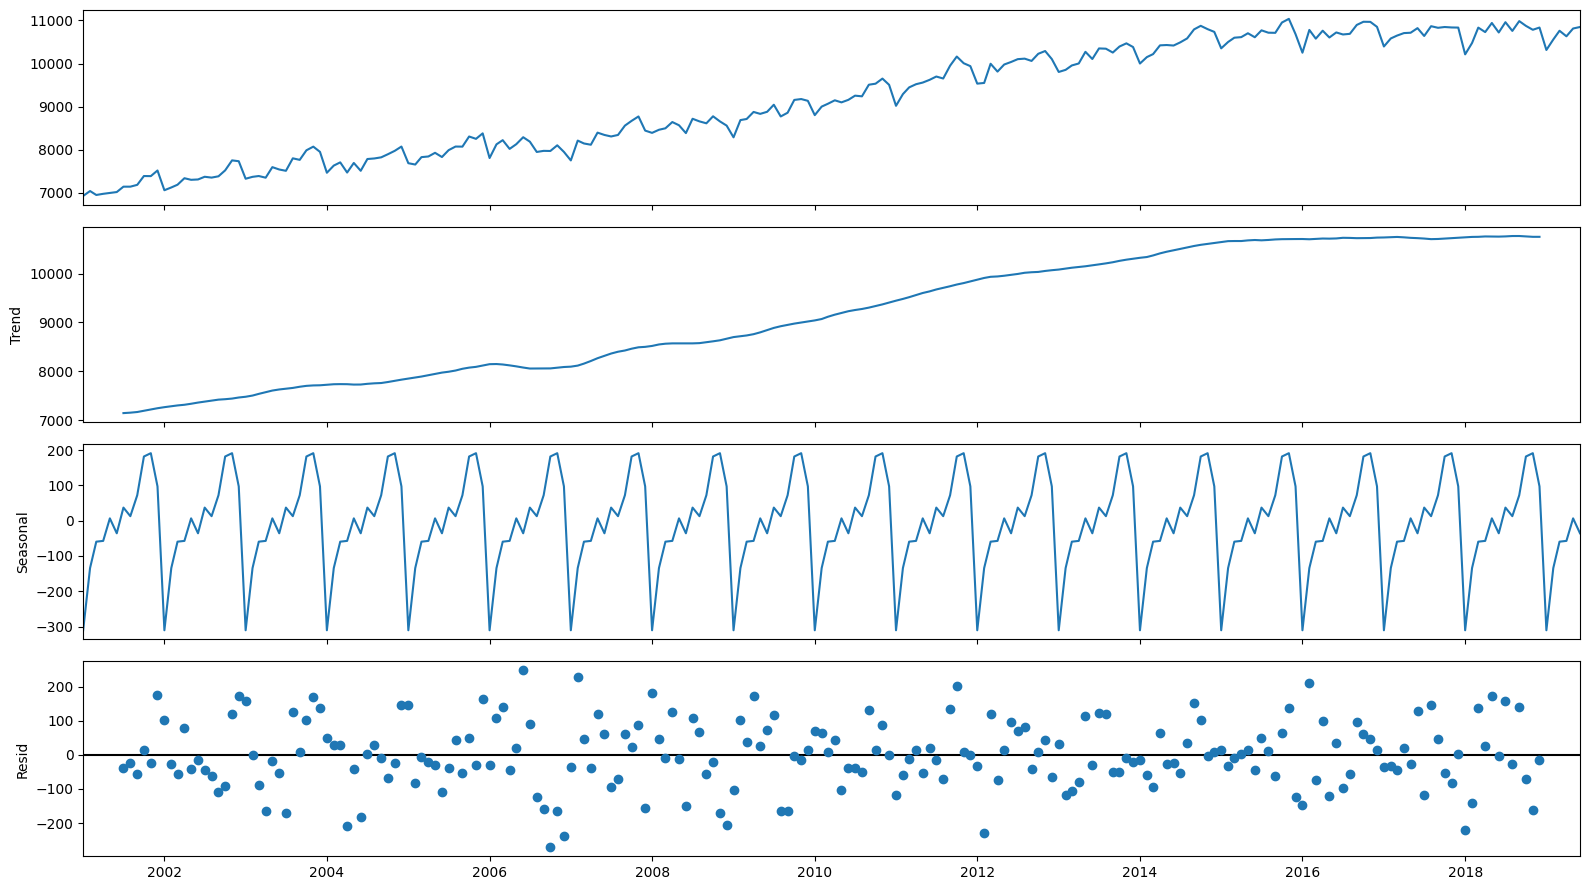

In [4]:
# Análisis de componentes
ocupados_componentes = seasonal_decompose(data[["Ocupados"]], model="additive")
fig = ocupados_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

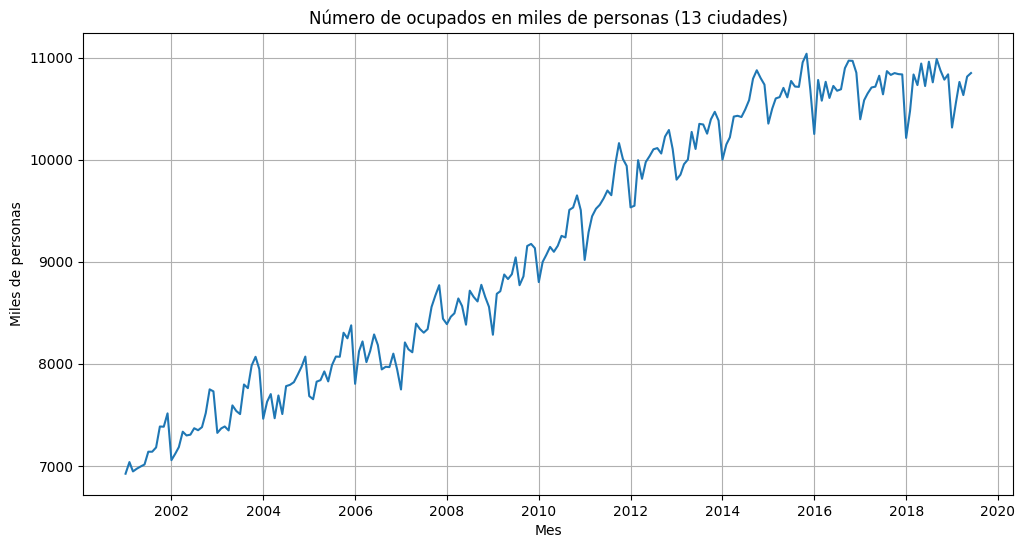

In [5]:
# Primero visualizamos la serie de ocupados
plt.figure(figsize=(12, 6))
plt.title("Número de ocupados en miles de personas (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Miles de personas")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

In [6]:
(data.shape[0] - 20) / data.shape[0]

0.9099099099099099

In [7]:
# Dividir datos en entrenamiento y prueba
train_len = len(data) - 20
train_ocupados = data[["Ocupados"]][:train_len]
test_ocupados = data[["Ocupados"]][train_len:]

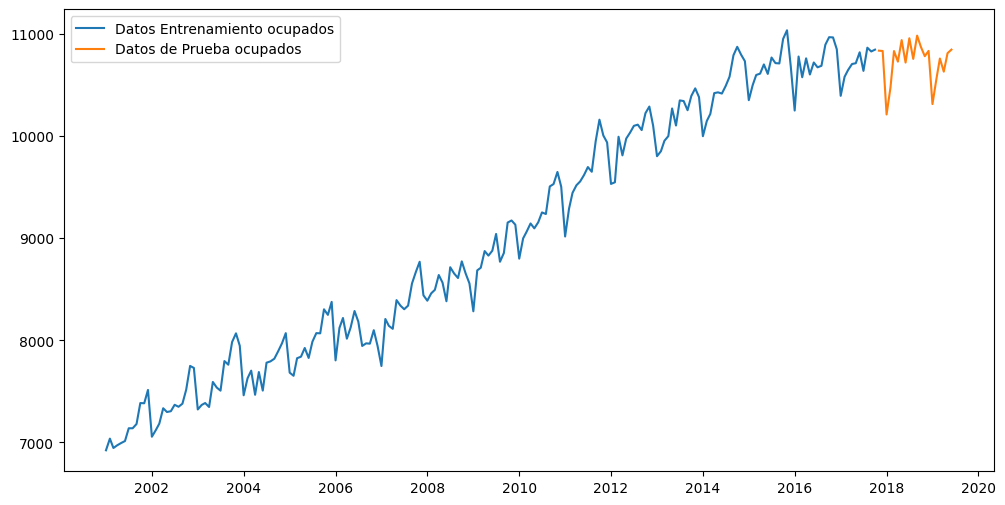

In [8]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados,label="Datos Entrenamiento ocupados")
plt.plot(test_ocupados,label="Datos de Prueba ocupados")
plt.legend()
plt.show()

In [9]:
## Considerando el dato actual
ma_coupado_2= train_ocupados.rolling(2,min_periods=2).mean()
ma_coupado_3= train_ocupados.rolling(3,min_periods=2).mean()
ma_coupado_4= train_ocupados.rolling(4,min_periods=2).mean()
ma_coupado_5= train_ocupados.rolling(5,min_periods=2).mean()

# Explicacion 

train_td.rolling(2,min_periods=2):

Crea una ventana móvil de tamaño 2
min_periods=2 significa que necesita al menos 2 observaciones para calcular el promedio

.mean(): Calcula el promedio de los valores en la ventana

### Ejemplo 

ma_coupado_3 = train_ocupados.rolling(3,min_periods=2).mean()

train_ocupados es tu serie de tiempo con los datos de personas ocupadas

.rolling(3, min_periods=2):

Crea una ventana móvil de tamaño 3 (esto significa que tomará 3 observaciones a la vez)
min_periods=2 indica que necesita al menos 2 observaciones para calcular el promedio
.mean() calcula el promedio de los valores en cada ventana

Por ejemplo, si tus datos fueran:

El cálculo sería así:

Para Enero: No hay suficientes datos previos (sería NA/NaN)

Para Febrero: Promedio de Enero y Febrero = (1000 + 1200)/2 = 1100

Para Marzo: Promedio de Enero, Febrero y Marzo = (1000 + 1200 + 1500)/3 = 1233.33

Para Abril: Promedio de Febrero, Marzo y Abril = (1200 + 1500 + 1300)/3 = 1333.33

Para Mayo: Promedio de Marzo, Abril y Mayo = (1500 + 1300 + 1400)/3 = 1400

El parámetro min_periods=2 significa que calculará el promedio incluso si solo hay 2 valores disponibles en la ventana (esto es útil especialmente al inicio de la serie). Si no tuviéramos este parámetro, necesitaríamos los 3 valores completos para comenzar a calcular promedios.

Este método es útil para suavizar la serie de tiempo y reducir las fluctuaciones aleatorias, ayudando a ver mejor la tendencia general de los datos.


In [10]:
ma_coupado_2= train_ocupados.shift().rolling(2,min_periods=2).mean()
ma_coupado_3= train_ocupados.shift().rolling(3,min_periods=2).mean()
ma_coupado_4= train_ocupados.shift().rolling(4,min_periods=2).mean()
ma_coupado_5= train_ocupados.shift().rolling(5,min_periods=2).mean()

In [12]:
def fore_ma(datos,w,h):
  data=datos.copy()
  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value]= data[-w:].mean()
  return data[-h:]

In [13]:
ma_coupado_2_f= fore_ma(train_ocupados,2,20)
ma_coupado_3_f= fore_ma(train_ocupados,3,20)
ma_coupado_4_f= fore_ma(train_ocupados,4,20)
ma_coupado_5_f= fore_ma(train_ocupados,5,20)

In [14]:
rmse_ma_coupado_2 = np.sqrt(mean_squared_error(test_ocupados,ma_coupado_2_f ))
rmse_ma_coupado_3 = np.sqrt(mean_squared_error(test_ocupados,ma_coupado_3_f ))
rmse_ma_coupado_4 = np.sqrt(mean_squared_error(test_ocupados,ma_coupado_4_f ))
rmse_ma_coupado_5 = np.sqrt(mean_squared_error(test_ocupados,ma_coupado_5_f ))

In [15]:
print(rmse_ma_coupado_2, rmse_ma_coupado_3 ,rmse_ma_coupado_4 ,rmse_ma_coupado_5)


225.9658896316463 227.7088541346497 219.38077771853222 217.7141121313523


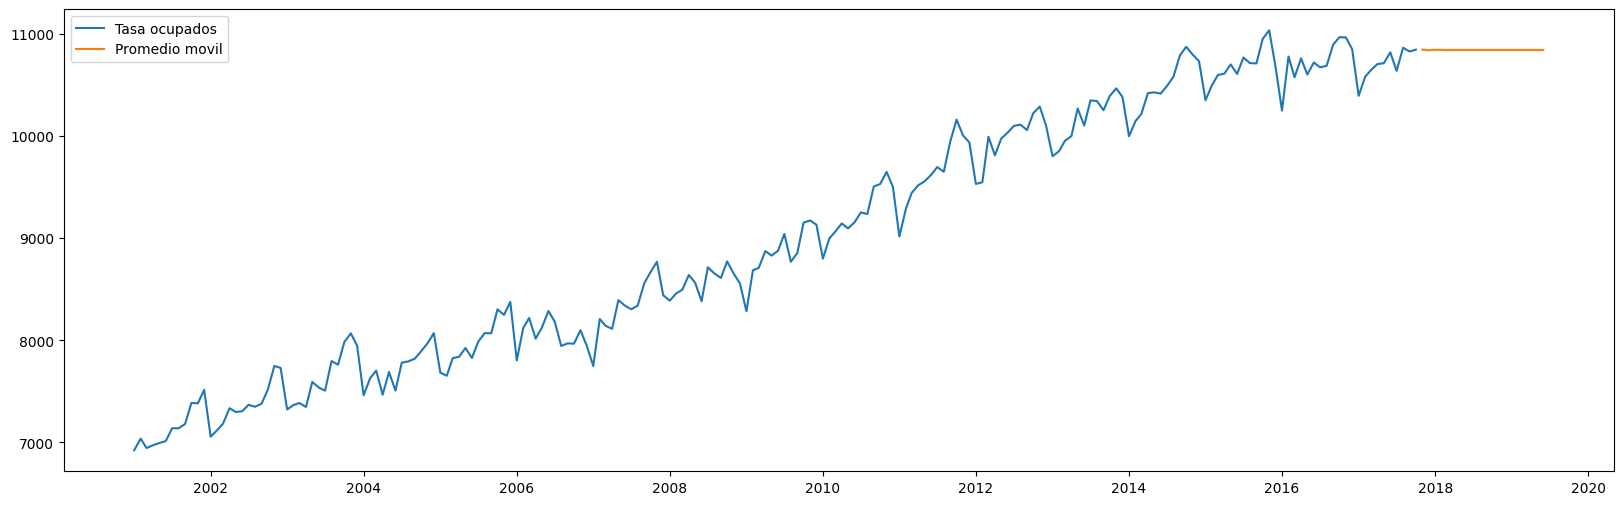

In [16]:
fig = plt.figure(figsize=(20, 6))
plt.plot(train_ocupados,label="Tasa ocupados")
plt.plot(ma_coupado_3_f,label="Promedio movil")
plt.legend()
plt.show()

In [17]:
# 1. Suavización Exponencial Simple
ets_ocupado_simple = ETSModel(endog=train_ocupados["Ocupados"], error="add")
ets_ocupado_simple_result = ets_ocupado_simple.fit()


c:\Users\Pipicano\Music\Semester I\Aprendizaje Automatico III\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [18]:
point_ocupado_forecast=ets_ocupado_simple_result.forecast(20)


In [19]:
ci = ets_ocupado_simple_result.get_prediction(start = point_ocupado_forecast.index[0],
                                end = point_ocupado_forecast.index[-1])

In [20]:
conf_ocupado_forecast = ci.pred_int(alpha=0.1)  # Obtiene intervalos de confianza del 95%
limits_ocupado = ci.predicted_mean  # Obtiene los valores pronosticados

# Se combinan en un DataFrame
preds_ocupado = pd.concat([limits_ocupado, conf_ocupado_forecast], axis=1)
preds_ocupado.columns = ['Point_forecast', 'lower_95', 'upper_95']

In [22]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(preds.index ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

NameError: name 'train_td' is not defined

<Figure size 1200x600 with 0 Axes>

In [23]:
rmse_ocupado = np.sqrt(mean_squared_error(test_ocupados,point_ocupado_forecast ))
print(rmse_ocupado)

224.92854727063406


In [24]:
ets_ocupado_holt_simple = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend="add")
ets_ocupado_holt_simple_result = ets_ocupado_holt_simple.fit()

point_ocupado_holt_forecast=ets_ocupado_holt_simple_result.forecast(20)

ci = ets_ocupado_holt_simple_result.get_prediction(start = point_ocupado_holt_forecast.index[0],
                                end = point_ocupado_holt_forecast.index[-1])

conf_ocupado_holt_forecast = ci.pred_int(alpha=0.05)  # Obtiene intervalos de confianza del 95%
limits_ocupado_holt = ci.predicted_mean  # Obtiene los valores pronosticados

# Se combinan en un DataFrame
preds_ocupado_holt = pd.concat([limits_ocupado_holt, conf_ocupado_holt_forecast], axis=1)
preds_ocupado_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']


c:\Users\Pipicano\Music\Semester I\Aprendizaje Automatico III\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


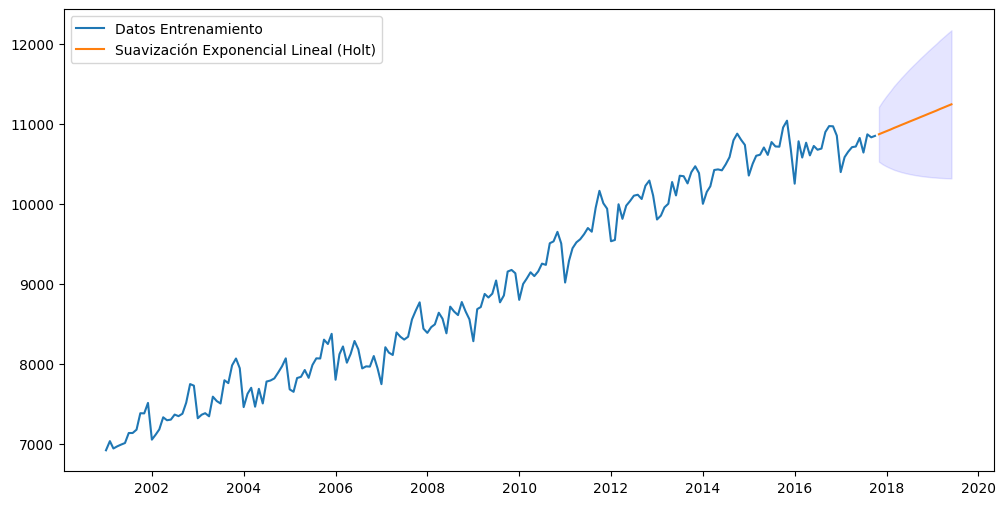

In [25]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados,label="Datos Entrenamiento")
plt.plot(preds_ocupado_holt['Point_forecast'],label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_ocupado_holt.index ,preds_ocupado_holt['lower_95'], preds_ocupado_holt['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [26]:
ets_ocupado_holt_Winters_simple = ETSModel(
    endog=train_ocupados["Ocupados"], 
    error="add", 
    trend="add", 
    seasonal="add"
)
ets_ocupado_holt_Winters_simple_result = ets_ocupado_holt_Winters_simple.fit()

point_ocupado_holt_Winters_forecast=ets_ocupado_holt_Winters_simple_result.forecast(20)

ci = ets_ocupado_holt_Winters_simple_result.get_prediction(
    start = point_ocupado_holt_Winters_forecast.index[0],
    end = point_ocupado_holt_Winters_forecast.index[-1]
)

conf_ocupado_holt_Winters_forecast = ci.pred_int(alpha=0.1)  # Obtiene intervalos de confianza del 95%
limits_ocupado_holt_Winters = ci.predicted_mean  # Obtiene los valores pronosticados

# Se combinan en un DataFrame
preds_ocupado_holt_Winters = pd.concat([limits_ocupado_holt_Winters, conf_ocupado_holt_Winters_forecast], axis=1)
preds_ocupado_holt_Winters.columns = ['Point_forecast', 'lower_95', 'upper_95']


c:\Users\Pipicano\Music\Semester I\Aprendizaje Automatico III\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


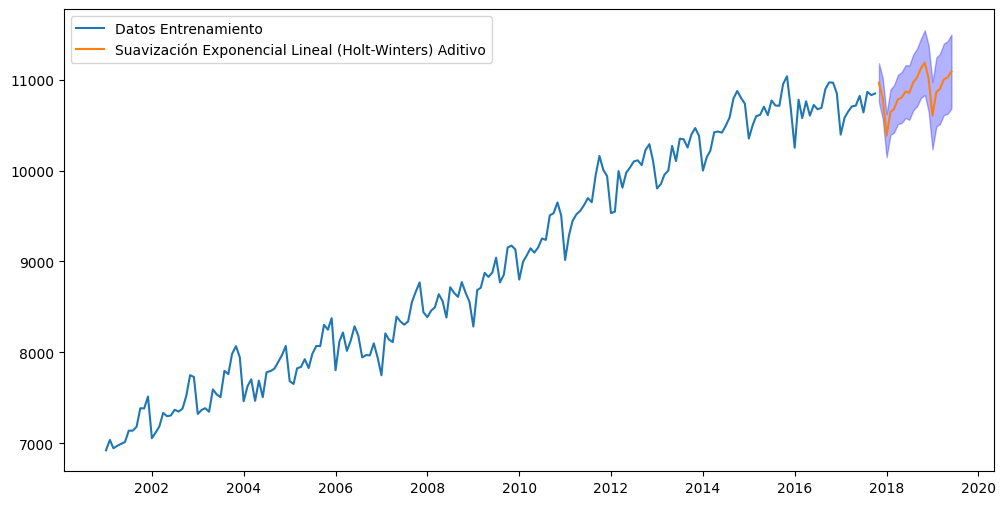

In [27]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados,label="Datos Entrenamiento")
plt.plot(
    preds_ocupado_holt_Winters['Point_forecast'],
    label="Suavización Exponencial Lineal (Holt-Winters) Aditivo"
)
plt.fill_between(
    preds_ocupado_holt_Winters.index,
    preds_ocupado_holt_Winters['lower_95'], 
    preds_ocupado_holt_Winters['upper_95'], 
    color='blue', 
    alpha=0.3
)
plt.legend()
plt.show()